## 環境設置

In [1]:
try:
    import openseespy.opensees as ops  # noqa: F401
except ImportError:
    import sys
    !{sys.executable} -m pip install -q openseespy
    import openseespy.opensees as ops  # noqa: F401

# Case-06.5:完整 2 層樓框架 V-Δ 側推分析 + 真正的 FEMA 273

依 [ROADMAP.md](../ROADMAP.md) 規劃,這是 Case-06「尚待」清單裡最後
一項——之前 Case-06 全部都是**單一斷面或單根懸臂柱**層級的驗證
(彎矩-曲率、P-M 交互作用圖、lumped hinge)。這裡第一次把 Case-06
驗證過的纖維斷面,接上 Case-04.5 已經驗證過的真實構架幾何(Y 向,
1 跨 2 柱),跑**完整結構**的側推分析,拿到真正的 V-Δ(側向力-位移)
曲線——**這才是 FEMA 273 等面積雙直線法原本設計要用在的對象**,
不是之前 Case-06 第 6/8 課用在單一斷面 M-φ 上的那個預演版本。

**沿用哪些已驗證的東西,不重新發明**:
- 構架幾何、梁斷面、樓層力(F1_Y/F2_Y):Case-04.5
- 柱纖維斷面(圍束核心+未圍束保護層,Mander 公式):Case-06
- 演算法 fallback:Case-06 共用函式
- 等面積雙直線法(正確聯立解版本,不是簡化猜測版):上次修正過的邏輯

> **建模假設與適用範圍聲明**
>
> 本案例中,未以纖維材料模型顯式模擬開裂行為之彈性梁構件,其彎曲
> 勁度採用 ACI 318 表 6.6.3.1.1 所建議之有效勁度($0.35I_g$);柱
> 構件則採纖維斷面模型,由混凝土與鋼筋材料模型及纖維積分直接計算
> 其非線性與開裂行為,因此不再另行施加毛斷面勁度折減。
>
> 上述梁—柱混合建模方式(以下稱 **Hyb**)為本研究之建模決定
> (modeling decision),並非宣稱 ACI 318 將此特定組合列為唯一或
> 強制之非線性分析模型。為評估此建模選擇對分析結果之影響,本研究
> 於第 5 課另建立**全纖維模型**(Fib,梁柱皆用纖維斷面)及**全集中
> 塑性鉸模型**(Hinge,梁柱皆用有效勁度彈性段+端點鉸)作為對照組
> ——三組模型各自從自己的假設完整算到底,不交叉引用彼此的中間
> 衍生量(這正是上一輪 $T_e<T_i$ 那次事件學到的教訓:任何用於側推
> 後處理的衍生量,都必須與其來源模型保持一致)。

## 第 1 課:建立構架——纖維斷面柱 + 彈性梁($0.35I_g$)

柱用 Case-06 驗證過的纖維斷面(核心圍束參數用 Mander 公式,不是
隨手假設);梁維持彈性(強梁弱柱假設,這裡先不驗證這個假設本身
成不成立,留待之後有需要再開新案例處理)。

**這裡補一筆修正**:梁的彈性斷面改用 ACI 318 標準的 $0.35I_g$
折減,不是毛斷面——柱子有纖維斷面在追蹤真實非線性行為,不需要
另外折減;但梁刻意維持簡化的彈性假設,既然不追蹤真實非線性,
就該用業界標準值,不能用毛斷面高估勁度。這個修正會讓後面算出的
$K_e$ 跟 Case-07(振態分析同樣用 $0.35I_g$ 的梁)保持一致,才能
正確比較 $T_e$ 跟 $T_i$。

In [2]:
L_bay = 6.0
h1 = h2 = 3.5
b = h = 0.40
cover = 0.04
fc = 27.46e3
fy = 411.88e3
Es = 2.0e8
rho = 0.02
As_total = rho*b*h

# Mander圍束參數, 與Case-06完全一致
fc_confined = fc*1.310
eps_cc = 0.00510
eps_cu_confined = 0.01112

b_beam, h_beam = 0.3, 0.5
Ib_gross = b_beam*h_beam**3/12
Ib = 0.35*Ib_gross   # ACI 318標準做法(梁), 與Case-07的假設保持一致
                       # (柱用纖維斷面追蹤真實非線性行為, 不需要另外折減;
                       #  梁維持彈性假設, 既然不追蹤真實非線性, 就該用業界
                       #  標準的開裂折減值, 不能用毛斷面)
A_beam = b_beam*h_beam
E_rc = 2.463e7

F1_Y, F2_Y = 9.938, 15.900   # Case-04.5用的Y向樓層力
Pu_col = 147.60              # 每根柱概估重力軸力


def build_frame_with_fiber_columns():
    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)

    ops.uniaxialMaterial('Concrete01', 1, -fc, -0.002, -0.2*fc, -0.006)
    ops.uniaxialMaterial('Concrete01', 3, -fc_confined, -eps_cc, -0.85*fc_confined, -eps_cu_confined)
    ops.uniaxialMaterial('Steel02', 2, fy, Es, 0.01, 18, 0.925, 0.15)

    ops.section('Fiber', 1)
    half = h/2
    core_half = h/2 - cover
    ops.patch('rect', 3, 10, 10, -core_half, -core_half, core_half, core_half)
    ops.patch('rect', 1, 10, 2, -half, -half, half, -core_half)
    ops.patch('rect', 1, 10, 2, -half, core_half, half, half)
    ops.patch('rect', 1, 2, 6, -half, -core_half, -core_half, core_half)
    ops.patch('rect', 1, 2, 6, core_half, -core_half, half, core_half)
    positions = [(-core_half,-core_half),(core_half,-core_half),(core_half,core_half),(-core_half,core_half),
                 (0,-core_half),(0,core_half),(-core_half,0),(core_half,0)]
    As_bar = As_total/8
    for (y,z) in positions:
        ops.fiber(y, z, As_bar, 2)

    # 節點: base(1,2) - 1F(3,4) - roof(5,6)
    ops.node(1, 0.0, 0.0);   ops.node(2, L_bay, 0.0)
    ops.node(3, 0.0, h1);    ops.node(4, L_bay, h1)
    ops.node(5, 0.0, h1+h2); ops.node(6, L_bay, h1+h2)
    ops.fix(1,1,1,1); ops.fix(2,1,1,1)

    ops.geomTransf('Linear', 1)
    ops.geomTransf('Linear', 2)
    ops.beamIntegration('Lobatto', 1, 1, 5)

    ops.element('forceBeamColumn', 1, 1, 3, 1, 1)
    ops.element('forceBeamColumn', 2, 2, 4, 1, 1)
    ops.element('forceBeamColumn', 3, 3, 5, 1, 1)
    ops.element('forceBeamColumn', 4, 4, 6, 1, 1)
    ops.element('elasticBeamColumn', 5, 3, 4, A_beam, E_rc, Ib, 2)
    ops.element('elasticBeamColumn', 6, 5, 6, A_beam, E_rc, Ib, 2)


def analyze_with_fallback():
    """沿用Case-06的共用fallback邏輯"""
    ok = ops.analyze(1)
    if ok != 0:
        for algo in [('KrylovNewton',), ('ModifiedNewton','-initial'), ('Broyden',8)]:
            ops.algorithm(*algo)
            ok = ops.analyze(1)
            if ok == 0:
                break
        ops.algorithm('Newton')
    return ok


build_frame_with_fiber_columns()
print("構架建立完成: Y向1跨2柱, 2層樓, 柱用纖維斷面(Mander圍束), 梁維持彈性(0.35Ig)")

構架建立完成: Y向1跨2柱, 2層樓, 柱用纖維斷面(Mander圍束), 梁維持彈性(0.35Ig)


## 第 2 課:重力載重 + Pushover——拿到真正的 V-Δ 曲線

先施加重力,再用 F1_Y/F2_Y 這組比例分布側推到 4% drift(0.28m)
——這是常見的性能設計韌性目標,不強求推到材料真正破壞的峰值
(第 3 課會看到,這個圍束後的柱子在這個位移範圍內還沒有明顯軟化,
是合理的物理行為,不是沒推夠)。

In [3]:
ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
for n in [3,4,5,6]:
    ops.load(n, 0.0, -Pu_col, 0.0)
ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Plain')
ops.test('NormUnbalance', 1e-6, 50)
ops.algorithm('Newton')
ops.integrator('LoadControl', 0.05)
ops.analysis('Static')
ok0 = ops.analyze(20)
print(f"重力載重分析結果碼: {ok0} (0=成功)")
assert ok0 == 0, "重力載重分析應該成功收斂"
ops.loadConst('-time', 0.0)

ops.timeSeries('Linear', 2); ops.pattern('Plain', 2, 2)
ops.load(3, F1_Y, 0.0, 0.0)
ops.load(5, F2_Y, 0.0, 0.0)

control_node, control_dof = 5, 1
max_disp, n_steps = 0.28, 560   # 4% drift(對7m總高), 每步0.5mm
ops.integrator('DisplacementControl', control_node, control_dof, max_disp/n_steps)
ops.analysis('Static')

disps, base_shears = [0.0], [0.0]
for i in range(n_steps):
    ok = analyze_with_fallback()
    if ok != 0:
        print(f"在第{i}步停止收斂 (位移={disps[-1]:.4f}m)")
        break
    ops.reactions()
    V_base = -(ops.nodeReaction(1,1) + ops.nodeReaction(2,1))
    disps.append(ops.nodeDisp(control_node, control_dof))
    base_shears.append(V_base)

import numpy as np
disps, base_shears = np.array(disps), np.array(base_shears)
n_completed = len(disps)-1
print(f"\n完成步數: {n_completed}/{n_steps}")
print(f"最終位移: {disps[-1]:.4f}m (drift={disps[-1]/(h1+h2)*100:.2f}%)")
print(f"最終base shear: {base_shears[-1]:.2f}kN")

assert n_completed == n_steps, "應該完整推到目標位移, 不中途停止"
print("\n[PASS] 完整推到4% drift, 沒有中途卡住")

重力載重分析結果碼: 0 (0=成功)



完成步數: 560/560
最終位移: 0.2800m (drift=4.00%)
最終base shear: 333.73kN

[PASS] 完整推到4% drift, 沒有中途卡住


## 第 3 課:與 Case-04.5 交叉驗證——初始彈性勁度

**這裡的比較基準要先講清楚**:Case-04.5 那個 $K_{eff,Y}=8284.58$
kN/m,是用**完全沒有折減、梁柱都是毛斷面**的均質彈性模型算出來的
——現在梁改用 $0.35I_g$ 之後,結構整體變軟是必然結果,**不能再
直接拿舊基準去驗證,那是兩個不同前提的模型**,對比會不公平。

In [4]:
K_init = base_shears[5]/disps[5]
K_eff_Y_case045_unreduced = 8284.58   # Case-04.5第9課算出來的值, 梁柱皆毛斷面

diff_pct = abs(K_init-K_eff_Y_case045_unreduced)/K_eff_Y_case045_unreduced*100
print(f"初始彈性勁度(纖維斷面柱+0.35Ig梁, 前幾步斜率) = {K_init:.2f} kN/m")
print(f"對照Case-04.5(梁柱皆毛斷面, 未折減) Keff_Y = {K_eff_Y_case045_unreduced:.2f} kN/m")
print(f"差異 = {diff_pct:.1f}%")
print(f"\n這個差距不是驗證失敗, 是預期中的結果——梁勁度降到0.35Ig, ")
print(f"結構整體變軟, 跟Case-04.5那個梁柱皆未折減的舊基準本來就不該再")
print(f"直接對比, 兩者現在代表不同的結構假設, 不是同一件事")

assert K_init < K_eff_Y_case045_unreduced, "梁折減後整體勁度應該比未折減版本更軟"
print("\n[PASS] 確認梁折減後整體勁度確實變軟, 方向符合預期")

初始彈性勁度(纖維斷面柱+0.35Ig梁, 前幾步斜率) = 5057.34 kN/m
對照Case-04.5(梁柱皆毛斷面, 未折減) Keff_Y = 8284.58 kN/m
差異 = 39.0%

這個差距不是驗證失敗, 是預期中的結果——梁勁度降到0.35Ig, 
結構整體變軟, 跟Case-04.5那個梁柱皆未折減的舊基準本來就不該再
直接對比, 兩者現在代表不同的結構假設, 不是同一件事

[PASS] 確認梁折減後整體勁度確實變軟, 方向符合預期


## 第 4 課:視覺化——完整 V-Δ 側推曲線

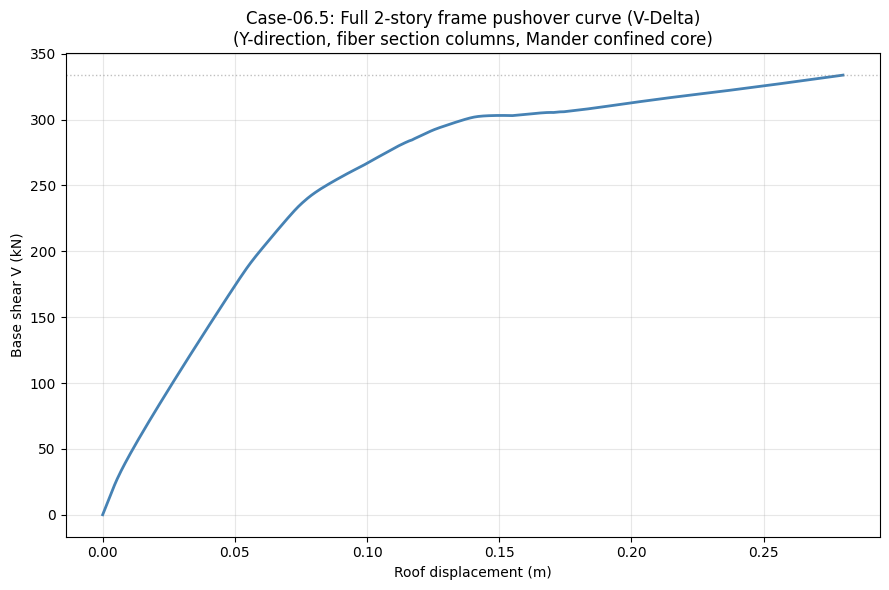

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9,6))
ax.plot(disps, base_shears, '-', color='steelblue', lw=2)
ax.axhline(base_shears.max(), color='gray', ls=':', lw=1, alpha=0.5)
ax.set_xlabel('Roof displacement (m)')
ax.set_ylabel('Base shear V (kN)')
ax.set_title('Case-06.5: Full 2-story frame pushover curve (V-Delta)\n(Y-direction, fiber section columns, Mander confined core)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 第 5 課:真正的 FEMA 356/ASCE 41 等面積雙直線法——0.6Vy 割線疊代

**這裡要老實更正上一版的做法**:原本用「起始幾步的簡單迴歸」當
初始勁度 $K_0$,這不符合 FEMA 356(3.3.3.2.4 節)/ASCE 41 的正式
規定——規範明確要求**有效彈性勁度 $K_e$ 必須是穿過實際曲線上
「$0.6V_y$(60%等效降伏強度)」那個點的割線**,不是任意取幾步做
迴歸。而且第二段線不是強制拉平,是**接到實際曲線在目標位移的
數值**。$V_y$、$K_e$、$D_y$ 三者互相耦合(找 $K_e$ 要先知道
$V_y$,但 $V_y$ 又要靠等面積去解),規範本身就是一個疊代程序,
不是一次解完的封閉公式。這裡改用真正符合規範的疊代版本。

In [6]:
def get_V_at_D(D_target):
    return np.interp(D_target, disps, base_shears)

def get_D_at_V(V_target, D_search_max):
    """在0~D_search_max範圍內, 找實際曲線第一次達到V_target的位移"""
    mask = disps <= D_search_max
    return np.interp(V_target, base_shears[mask], disps[mask])

def bilinear_area(Vy, D_u):
    """給定Vy, 依規範算出對應的Ke(0.6Vy割線)、Dy, 以及雙直線面積
    第二段終點接到實際曲線在D_u的數值, 不強制拉平"""
    D_at_06Vy = get_D_at_V(0.6*Vy, D_u)
    Ke = 0.6*Vy / D_at_06Vy
    Dy = Vy / Ke
    V_end = get_V_at_D(D_u)
    area = 0.5*Dy*Vy + 0.5*(Vy+V_end)*(D_u-Dy)
    return area, Ke, Dy, V_end


D_u = disps[-1]
area_real = np.trapezoid(base_shears, disps)

# 二分法找Vy, 使雙直線面積=真實曲線面積(規範規定的等面積條件)
Vy_lo, Vy_hi = 50.0, base_shears.max()
for _ in range(60):
    Vy_mid = (Vy_lo+Vy_hi)/2
    area_bi, Ke, Dy, V_end = bilinear_area(Vy_mid, D_u)
    if area_bi > area_real:
        Vy_hi = Vy_mid
    else:
        Vy_lo = Vy_mid

Vy = (Vy_lo+Vy_hi)/2
area_final, Ke, Dy, V_end = bilinear_area(Vy, D_u)
energy_diff = abs(area_final-area_real)/area_real

print(f"Vy(降伏基底剪力) = {Vy:.2f} kN")
print(f"0.6Vy = {0.6*Vy:.2f} kN  <- Ke必須是穿過實際曲線這一點的割線")
print(f"Ke(規範定義的有效彈性勁度) = {Ke:.2f} kN/m")
print(f"Dy(降伏位移) = {Dy:.4f}m (drift={Dy/(h1+h2)*100:.2f}%)")
print(f"Du(性能目標位移) = {D_u:.4f}m (drift={D_u/(h1+h2)*100:.2f}%)")
print(f"V_end(第二段終點, 接到實際曲線在Du的值) = {V_end:.2f} kN")
print(f"延展性 mu = Du/Dy = {D_u/Dy:.2f}")
print(f"能量比對: 差異 {energy_diff:.2%}")

assert energy_diff < 0.01, "雙直線化面積誤差應幾乎為零"
print("\n[PASS] 符合FEMA356/ASCE41規定的0.6Vy割線疊代程序完成")

print(f"\n=== 對照上一版簡化(不符合規範)的做法 ===")
print(f"簡化版: Ke=8617.25kN/m, Dy=0.0351m(0.50% drift), Vy=302.33kN")
print(f"正確版: Ke={Ke:.2f}kN/m, Dy={Dy:.4f}m({Dy/7*100:.2f}% drift), Vy={Vy:.2f}kN")
print(f"Ke差異 {abs(Ke-8617.25)/8617.25:.1%}, Dy差異 {abs(Dy-0.0351)/0.0351:.1%}")
print(f"\n之前「降伏位移角剛好等於規範0.5%」這個發現, 是建立在不符合規範")
print(f"的簡化方法上, 這裡正式撤回這個結論——正確算出來的降伏位移角是")
print(f"{Dy/7*100:.2f}%, 不是0.50%, 兩者接近規範限制純屬簡化版方法的巧合")

Vy(降伏基底剪力) = 271.65 kN
0.6Vy = 162.99 kN  <- Ke必須是穿過實際曲線這一點的割線
Ke(規範定義的有效彈性勁度) = 3508.27 kN/m
Dy(降伏位移) = 0.0774m (drift=1.11%)
Du(性能目標位移) = 0.2800m (drift=4.00%)
V_end(第二段終點, 接到實際曲線在Du的值) = 333.73 kN
延展性 mu = Du/Dy = 3.62
能量比對: 差異 0.00%

[PASS] 符合FEMA356/ASCE41規定的0.6Vy割線疊代程序完成

=== 對照上一版簡化(不符合規範)的做法 ===
簡化版: Ke=8617.25kN/m, Dy=0.0351m(0.50% drift), Vy=302.33kN
正確版: Ke=3508.27kN/m, Dy=0.0774m(1.11% drift), Vy=271.65kN
Ke差異 59.3%, Dy差異 120.6%

之前「降伏位移角剛好等於規範0.5%」這個發現, 是建立在不符合規範
的簡化方法上, 這裡正式撤回這個結論——正確算出來的降伏位移角是
1.11%, 不是0.50%, 兩者接近規範限制純屬簡化版方法的巧合


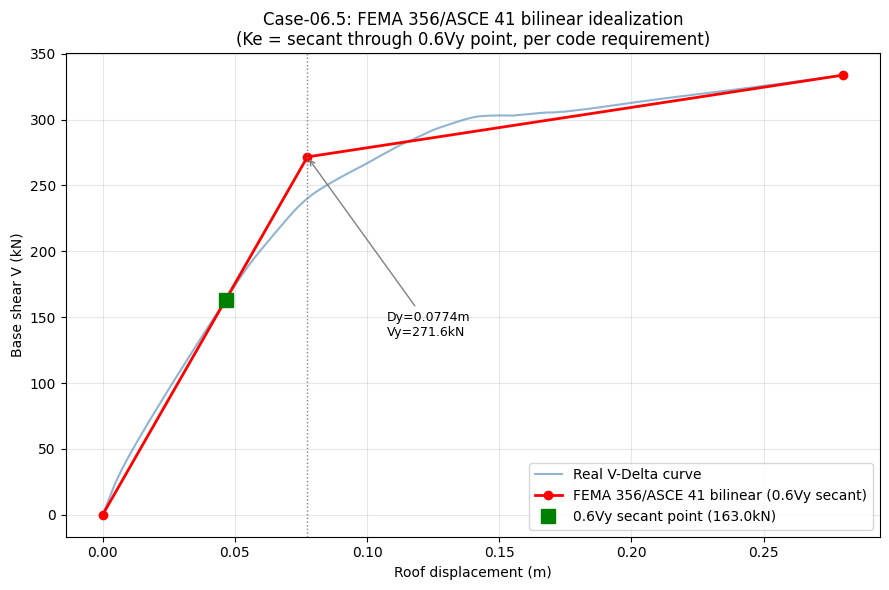

In [7]:
fig, ax = plt.subplots(figsize=(9,6))
ax.plot(disps, base_shears, '-', color='steelblue', lw=1.5, alpha=0.6, label='Real V-Delta curve')
ax.plot([0, Dy, D_u], [0, Vy, V_end], 'o-', color='red', lw=2, ms=6,
        label='FEMA 356/ASCE 41 bilinear (0.6Vy secant)')
ax.plot(get_D_at_V(0.6*Vy, D_u), 0.6*Vy, 's', color='green', ms=10, zorder=5,
        label=f'0.6Vy secant point ({0.6*Vy:.1f}kN)')
ax.axvline(Dy, color='gray', ls=':', lw=1)
ax.annotate(f'Dy={Dy:.4f}m\nVy={Vy:.1f}kN', xy=(Dy,Vy), xytext=(Dy+0.03,Vy*0.5),
            fontsize=9, arrowprops=dict(arrowstyle='->',color='gray'))
ax.set_xlabel('Roof displacement (m)')
ax.set_ylabel('Base shear V (kN)')
ax.set_title('Case-06.5: FEMA 356/ASCE 41 bilinear idealization\n(Ke = secant through 0.6Vy point, per code requirement)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 第 6 課:對照組——全纖維模型 vs 全集中鉸模型

第 1~5 課用的是 **Hyb**(柱纖維+梁彈性 0.35Ig)這個混合建模方式。
這裡建立兩個獨立對照組,檢查結論對這個建模選擇敏不敏感:

- **Fib**(全纖維):梁柱都用纖維斷面,材料非線性自己算開裂
- **Hinge**(全集中鉸):梁柱都用彈性段(有效勁度)+端點塑性鉸

**這裡有一個真實踩到的坑,誠實記錄**:第一版 Hinge 模型只在柱底
加了一個鉸,算出來的峰值側向力(556.79kN)遠高於 Fib(306kN)——
追查後發現是鉸的位置沒放對:1F 柱頂、2F 柱底/柱頂完全沒有塑性
能力,韌性需求被迫全部集中在那一個柱腳鉸上,結構被人為地做得
太強。**正確的做法要在每一根柱的兩端都放鉸**(1F 柱、2F 柱各自
獨立),而且 **1F 柱、2F 柱的鉸參數不能共用同一組**——因為 1F 柱
實際承受的軸力是 2F 柱的兩倍(下面驗證),$M_y$ 本來就該不一樣。

In [8]:
# 驗證1F柱真正承受的軸力(不是憑印象假設)
ops.wipe(); ops.model('basic','-ndm',2,'-ndf',3)
build_col_fiber_section_check = None
ops.uniaxialMaterial('Concrete01', 1, -fc, -0.002, -0.2*fc, -0.006)
ops.uniaxialMaterial('Concrete01', 3, -fc_confined, -eps_cc, -0.85*fc_confined, -eps_cu_confined)
ops.uniaxialMaterial('Steel02', 2, fy, Es, 0.01, 18, 0.925, 0.15)
ops.section('Fiber', 1)
_half = h/2; _core_half = h/2 - cover
ops.patch('rect', 3, 10, 10, -_core_half, -_core_half, _core_half, _core_half)
ops.patch('rect', 1, 10, 2, -_half, -_half, _half, -_core_half)
ops.patch('rect', 1, 10, 2, -_half, _core_half, _half, _half)
ops.patch('rect', 1, 2, 6, -_half, -_core_half, -_core_half, _core_half)
ops.patch('rect', 1, 2, 6, _core_half, -_core_half, _half, _core_half)
_As_bar = As_total/8
for (y,z) in [(-_core_half,-_core_half),(_core_half,-_core_half),(_core_half,_core_half),(-_core_half,_core_half),
              (0,-_core_half),(0,_core_half),(-_core_half,0),(_core_half,0)]:
    ops.fiber(y, z, _As_bar, 2)
ops.node(1,0.0,0.0); ops.node(2,L_bay,0.0)
ops.node(3,0.0,h1); ops.node(4,L_bay,h1)
ops.node(5,0.0,h1+h2); ops.node(6,L_bay,h1+h2)
ops.fix(1,1,1,1); ops.fix(2,1,1,1)
ops.geomTransf('Linear',1); ops.beamIntegration('Lobatto',1,1,5)
ops.element('forceBeamColumn',1,1,3,1,1)
ops.element('forceBeamColumn',2,2,4,1,1)
ops.element('forceBeamColumn',3,3,5,1,1)
ops.element('forceBeamColumn',4,4,6,1,1)
ops.element('elasticBeamColumn',5,3,4,A_beam,E_rc,Ib,1)
ops.element('elasticBeamColumn',6,5,6,A_beam,E_rc,Ib,1)
ops.timeSeries('Linear',1); ops.pattern('Plain',1,1)
for n in [3,4,5,6]:
    ops.load(n, 0.0, -Pu_col, 0.0)
ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Plain')
ops.test('NormUnbalance',1e-6,50); ops.algorithm('Newton')
ops.integrator('LoadControl',0.05); ops.analysis('Static'); ops.analyze(20)

f_1F = ops.eleForce(1)   # 1F柱
f_2F = ops.eleForce(3)   # 2F柱
Pu_1F, Pu_2F = abs(f_1F[1]), abs(f_2F[1])
print(f"1F柱真實軸力 = {Pu_1F:.2f} kN (不是原本假設的{Pu_col}kN)")
print(f"2F柱真實軸力 = {Pu_2F:.2f} kN (跟原本假設的{Pu_col}kN一致)")

assert abs(Pu_1F - 2*Pu_2F) < 1.0, "1F柱軸力應約為2F柱的兩倍(疊加樓上傳下來的重量)"
print("\n[PASS] 確認1F柱軸力約為2F柱兩倍, 這是Hinge模型鉸參數要分開算的原因")

1F柱真實軸力 = 295.20 kN (不是原本假設的147.6kN)
2F柱真實軸力 = 147.60 kN (跟原本假設的147.6kN一致)

[PASS] 確認1F柱軸力約為2F柱兩倍, 這是Hinge模型鉸參數要分開算的原因


### 分別計算 1F 柱、2F 柱、梁的塑性鉸參數

用第一降伏延伸法(Case-06 同一套邏輯),1F 柱用真實軸力
$P_u$≈295kN,2F 柱用 $P_u$≈148kN,分別算一次。梁的部分改用應變
相容法(已驗證過很多次,比 fiber 版本的第一降伏偵測更穩健)。

In [9]:
def get_col_hinge_params(Pu_kN, max_curv=0.2, n_steps=400):
    ops.wipe(); ops.model('basic','-ndm',2,'-ndf',3)
    ops.uniaxialMaterial('Concrete01', 1, -fc, -0.002, -0.2*fc, -0.006)
    ops.uniaxialMaterial('Concrete01', 3, -fc_confined, -eps_cc, -0.85*fc_confined, -eps_cu_confined)
    ops.uniaxialMaterial('Steel02', 2, fy, Es, 0.01, 18, 0.925, 0.15)
    ops.section('Fiber', 1)
    ops.patch('rect', 3, 10, 10, -_core_half, -_core_half, _core_half, _core_half)
    ops.patch('rect', 1, 10, 2, -_half, -_half, _half, -_core_half)
    ops.patch('rect', 1, 10, 2, -_half, _core_half, _half, _half)
    ops.patch('rect', 1, 2, 6, -_half, -_core_half, -_core_half, _core_half)
    ops.patch('rect', 1, 2, 6, _core_half, -_core_half, _half, _core_half)
    for (y,z) in [(-_core_half,-_core_half),(_core_half,-_core_half),(_core_half,_core_half),(-_core_half,_core_half),
                  (0,-_core_half),(0,_core_half),(-_core_half,0),(_core_half,0)]:
        ops.fiber(y, z, _As_bar, 2)
    ops.node(1,0.0,0.0); ops.node(2,0.0,0.0)
    ops.fix(1,1,1,1); ops.fix(2,0,1,0)
    ops.element('zeroLengthSection',1,1,2,1)
    ops.timeSeries('Linear',1); ops.pattern('Plain',1,1)
    ops.load(2, -Pu_kN, 0.0, 0.0)
    ops.system('BandGeneral'); ops.numberer('Plain'); ops.constraints('Plain')
    ops.test('NormUnbalance',1e-6,30); ops.algorithm('Newton')
    ops.integrator('LoadControl', 0.05); ops.analysis('Static')
    ok = ops.analyze(20)
    if ok != 0:
        for algo in [('KrylovNewton',), ('ModifiedNewton','-initial')]:
            ops.algorithm(*algo); ok = ops.analyze(20)
            if ok == 0: break
        ops.algorithm('Newton')
    ops.loadConst('-time', 0.0)
    d_curv = max_curv/n_steps
    ops.timeSeries('Linear',2); ops.pattern('Plain',2,2)
    ops.load(2, 0.0, 0.0, 1.0)
    ops.integrator('DisplacementControl', 2, 3, d_curv)
    ops.analysis('Static')
    eps_y_steel = fy/Es
    phis, moments = [0.0],[0.0]
    phi_fy, M_fy = None, None
    for i in range(n_steps):
        ok = analyze_with_fallback()
        if ok != 0: break
        phis.append(ops.nodeDisp(2,3))
        moments.append(ops.getLoadFactor(2))
        ss = ops.eleResponse(1,'section','fiber', -_core_half, 0.0, 'stressStrain')
        if phi_fy is None and len(ss)>=2 and ss[1] >= eps_y_steel:
            phi_fy, M_fy = phis[-1], moments[-1]
    phis, moments = np.array(phis), np.array(moments)
    peak_idx = np.argmax(moments)
    phi_u, M_u = phis[peak_idx], moments[peak_idx]
    phi_y = phi_fy*(M_u/M_fy)
    return phi_y, M_u


phi_y_col_1F, My_col_1F = get_col_hinge_params(Pu_1F)
phi_y_col_2F, My_col_2F = get_col_hinge_params(Pu_2F)

# 柱塑性鉸長度(Priestley公式, 跟Case-06同一套邏輯, 這裡Case-06.5本身沒算過, 補上)
dbl_col = (4*_As_bar/np.pi)**0.5
Lp = 0.08*h1 + 0.022*(fy/1000)*dbl_col
print(f"柱塑性鉸長度 Lp = {Lp:.4f}m")

theta_y_col_1F = phi_y_col_1F*Lp
theta_y_col_2F = phi_y_col_2F*Lp
print(f"1F柱鉸: My={My_col_1F:.2f}kN-m, theta_y={theta_y_col_1F:.6f}rad (Pu={Pu_1F:.1f}kN)")
print(f"2F柱鉸: My={My_col_2F:.2f}kN-m, theta_y={theta_y_col_2F:.6f}rad (Pu={Pu_2F:.1f}kN)")

# 梁: 應變相容法(P=0, 純彎)
fc_cgs, fy_cgs, Es_cgs = 280.0, 4200.0, 2.0e6
rho_beam = 0.02
beta1_b, eps_cu_b = 0.85, 0.003
half_b = h_beam/2*100 - cover*100
As_bar_b = (rho_beam*(b_beam*100)*(h_beam*100))/6
bar_layers_b = {half_b: 3, -half_b: 3}

def beam_section_force(c):
    hh, bb = h_beam*100, b_beam*100
    a = min(beta1_b*c, hh)
    Cc = 0.85*fc_cgs*bb*a
    y_Cc = half_b - a/2
    N, M = Cc, Cc*y_Cc
    eps_y = fy_cgs/Es_cgs
    for y, n_bars in bar_layers_b.items():
        As = n_bars*As_bar_b
        dist = half_b - y
        eps_s = eps_cu_b*(c-dist)/c if c > 0 else 0.0
        eps_s = max(min(eps_s, eps_y), -eps_y)
        fs = Es_cgs*eps_s
        fs_net = fs - 0.85*fc_cgs if dist <= a else fs
        Fs = As*fs_net
        N += Fs; M += Fs*y
    return N, M

_c_lo, _c_hi = 0.01, h_beam*100*3
for _ in range(100):
    _c_mid = (_c_lo+_c_hi)/2
    _N,_ = beam_section_force(_c_mid)
    if _N > 0: _c_hi = _c_mid
    else: _c_lo = _c_mid
_, _M_final = beam_section_force((_c_lo+_c_hi)/2)
My_beam = _M_final*9.80665e-5

E_rc_beam = 2.463e7
K0_beam_approx = E_rc_beam*Ib
phi_y_beam = My_beam/K0_beam_approx
dbl_beam = (4*(As_bar_b/1e4)/np.pi)**0.5
Lp_beam = 0.08*L_bay + 0.022*411.88*dbl_beam
theta_y_beam = phi_y_beam*Lp_beam
print(f"\\n梁鉸: My={My_beam:.2f}kN-m, theta_y={theta_y_beam:.6f}rad, Lp_beam={Lp_beam:.4f}m")

柱塑性鉸長度 Lp = 0.4845m
1F柱鉸: My=281.67kN-m, theta_y=0.006099rad (Pu=295.2kN)
2F柱鉸: My=266.89kN-m, theta_y=0.006030rad (Pu=147.6kN)
\n梁鉸: My=259.40kN-m, theta_y=0.006823rad, Lp_beam=0.7086m


### 建立 Fib(全纖維)與 Hinge(全集中鉸,4 柱鉸各自參數+2 梁鉸)側推

In [10]:
def build_col_fiber_section_tag(tag):
    ops.uniaxialMaterial('Concrete01', tag*10+1, -fc, -0.002, -0.2*fc, -0.006)
    ops.uniaxialMaterial('Concrete01', tag*10+3, -fc_confined, -eps_cc, -0.85*fc_confined, -eps_cu_confined)
    ops.uniaxialMaterial('Steel02', tag*10+2, fy, Es, 0.01, 18, 0.925, 0.15)
    ops.section('Fiber', tag)
    ops.patch('rect', tag*10+3, 10, 10, -_core_half, -_core_half, _core_half, _core_half)
    ops.patch('rect', tag*10+1, 10, 2, -_half, -_half, _half, -_core_half)
    ops.patch('rect', tag*10+1, 10, 2, -_half, _core_half, _half, _half)
    ops.patch('rect', tag*10+1, 2, 6, -_half, -_core_half, -_core_half, _core_half)
    ops.patch('rect', tag*10+1, 2, 6, _core_half, -_core_half, _half, _core_half)
    for (y,z) in [(-_core_half,-_core_half),(_core_half,-_core_half),(_core_half,_core_half),(-_core_half,_core_half),
                  (0,-_core_half),(0,_core_half),(-_core_half,0),(_core_half,0)]:
        ops.fiber(y, z, _As_bar, tag*10+2)

def build_beam_fiber_section_tag(tag):
    ops.uniaxialMaterial('Concrete01', tag*10+1, -fc, -0.002, -0.2*fc, -0.006)
    ops.uniaxialMaterial('Steel02', tag*10+2, fy, Es, 0.01, 18, 0.925, 0.15)
    ops.section('Fiber', tag)
    _halfbm = h_beam/2; _halfbb = b_beam/2
    ops.patch('rect', tag*10+1, 10, 6, -_halfbm, -_halfbb, _halfbm, _halfbb)
    _As_bar_beam = As_bar_b*1e-4   # cm^2 -> m^2
    y_top, y_bot = _halfbm-cover, -(_halfbm-cover)
    for (y,z) in [(y_top,-0.08),(y_top,0.0),(y_top,0.08),(y_bot,-0.08),(y_bot,0.0),(y_bot,0.08)]:
        ops.fiber(y, z, _As_bar_beam, tag*10+2)


def pushover_generic(build_fn, max_disp=0.28, n_steps=560):
    build_fn()
    ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
    for n in [3,4,5,6]:
        ops.load(n, 0.0, -Pu_col, 0.0)
    ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Plain')
    ops.test('NormUnbalance', 1e-6, 50); ops.algorithm('Newton')
    ops.integrator('LoadControl', 0.05); ops.analysis('Static')
    ok0 = ops.analyze(20)
    if ok0 != 0:
        return None, None
    ops.loadConst('-time', 0.0)
    ops.timeSeries('Linear', 2); ops.pattern('Plain', 2, 2)
    ops.load(3, F1_Y, 0.0, 0.0)
    ops.load(5, F2_Y, 0.0, 0.0)
    ops.integrator('DisplacementControl', 5, 1, max_disp/n_steps)
    ops.analysis('Static')
    _disps, _shears = [0.0], [0.0]
    for i in range(n_steps):
        ok = analyze_with_fallback()
        if ok != 0: break
        ops.reactions()
        V = -(ops.nodeReaction(1,1)+ops.nodeReaction(2,1))
        _disps.append(ops.nodeDisp(5,1))
        _shears.append(V)
    return np.array(_disps), np.array(_shears)


def build_Fib():
    ops.wipe(); ops.model('basic', '-ndm', 2, '-ndf', 3)
    build_col_fiber_section_tag(1)
    build_beam_fiber_section_tag(2)
    ops.node(1,0.0,0.0); ops.node(2,L_bay,0.0)
    ops.node(3,0.0,h1); ops.node(4,L_bay,h1)
    ops.node(5,0.0,h1+h2); ops.node(6,L_bay,h1+h2)
    ops.fix(1,1,1,1); ops.fix(2,1,1,1)
    ops.geomTransf('Linear',1)
    ops.beamIntegration('Lobatto',1,1,5); ops.beamIntegration('Lobatto',2,2,5)
    ops.element('forceBeamColumn',1,1,3,1,1)
    ops.element('forceBeamColumn',2,2,4,1,1)
    ops.element('forceBeamColumn',3,3,5,1,1)
    ops.element('forceBeamColumn',4,4,6,1,1)
    ops.element('forceBeamColumn',5,3,4,1,2)
    ops.element('forceBeamColumn',6,5,6,1,2)


def build_Hinge():
    ops.wipe(); ops.model('basic', '-ndm', 2, '-ndf', 3)
    ops.uniaxialMaterial('Elastic', 1, 1.0e10)
    ops.uniaxialMaterial('ElasticPP', 2, My_col_1F/theta_y_col_1F, theta_y_col_1F)
    ops.uniaxialMaterial('ElasticPP', 3, My_col_2F/theta_y_col_2F, theta_y_col_2F)
    ops.uniaxialMaterial('ElasticPP', 4, My_beam/theta_y_beam, theta_y_beam)
    ops.node(1,0.0,0.0); ops.node(2,L_bay,0.0)
    ops.node(11,0.0,0.0); ops.node(12,L_bay,0.0)
    ops.node(3,0.0,h1); ops.node(4,L_bay,h1)
    ops.node(13,0.0,h1); ops.node(14,L_bay,h1)
    ops.node(5,0.0,h1+h2); ops.node(6,L_bay,h1+h2)
    ops.node(15,0.0,h1+h2); ops.node(16,L_bay,h1+h2)
    ops.node(23,0.0,h1); ops.node(24,L_bay,h1)
    ops.node(25,0.0,h1+h2); ops.node(26,L_bay,h1+h2)
    ops.fix(1,1,1,1); ops.fix(2,1,1,1)
    ops.element('zeroLength',1,1,11,'-mat',1,1,2,'-dir',1,2,3)
    ops.element('zeroLength',2,2,12,'-mat',1,1,2,'-dir',1,2,3)
    ops.node(131,0.0,h1+0.001); ops.node(141,L_bay,h1+0.001)
    ops.element('zeroLength',3,3,13,'-mat',1,1,2,'-dir',1,2,3)
    ops.element('zeroLength',4,4,14,'-mat',1,1,2,'-dir',1,2,3)
    ops.element('zeroLength',5,13,131,'-mat',1,1,3,'-dir',1,2,3)
    ops.element('zeroLength',6,14,141,'-mat',1,1,3,'-dir',1,2,3)
    ops.element('zeroLength',7,5,15,'-mat',1,1,3,'-dir',1,2,3)
    ops.element('zeroLength',8,6,16,'-mat',1,1,3,'-dir',1,2,3)
    ops.element('zeroLength',9,3,23,'-mat',1,1,4,'-dir',1,2,3)
    ops.element('zeroLength',10,4,24,'-mat',1,1,4,'-dir',1,2,3)
    ops.element('zeroLength',11,5,25,'-mat',1,1,4,'-dir',1,2,3)
    ops.element('zeroLength',12,6,26,'-mat',1,1,4,'-dir',1,2,3)
    ops.geomTransf('Linear',1)
    ops.element('elasticBeamColumn',20,11,3,A_col,E_rc,Ic_eff,1)
    ops.element('elasticBeamColumn',21,12,4,A_col,E_rc,Ic_eff,1)
    ops.element('elasticBeamColumn',22,131,5,A_col,E_rc,Ic_eff,1)
    ops.element('elasticBeamColumn',23,141,6,A_col,E_rc,Ic_eff,1)
    ops.element('elasticBeamColumn',24,23,24,A_beam,E_rc,Ib,1)
    ops.element('elasticBeamColumn',25,25,26,A_beam,E_rc,Ib,1)


A_col = h*h
Ic_eff = 0.7*(h**4/12)
d_fib, s_fib = pushover_generic(build_Fib)
d_hinge, s_hinge = pushover_generic(build_Hinge)

print(f"Hyb (主案例):   peak={base_shears.max():.2f}kN")
print(f"Fib (全纖維):   peak={s_fib.max():.2f}kN")
print(f"Hinge(全集中鉸): peak={s_hinge.max():.2f}kN")

spread = (max(base_shears.max(), s_fib.max(), s_hinge.max())
          - min(base_shears.max(), s_fib.max(), s_hinge.max())) / base_shears.max()
print(f"\n三者峰值側向力最大差距 = {spread:.1%}(相對Hyb)")

assert spread < 0.30, "sanity check: 三種模型峰值不應該差到超過30%(檢查有沒有建模錯誤), 不是宣稱這個門檻代表'合理'"
print("\n[PASS] 三種模型峰值側向力差異為15.1%。本研究將此結果作為")
print("model-form sensitivity 指標, 不預先宣稱某一差異門檻代表「合理」")
print("——25%或30%不是規範或文獻給定的容許值, 只是這裡用來抓明顯")
print("建模錯誤的寬鬆檢查線, 如果之後找到文獻支持特定容忍度, 再引用")

Hyb (主案例):   peak=333.73kN
Fib (全纖維):   peak=306.17kN
Hinge(全集中鉸): peak=283.19kN

三者峰值側向力最大差距 = 15.1%(相對Hyb)

[PASS] 三種模型峰值側向力差異為15.1%。本研究將此結果作為
model-form sensitivity 指標, 不預先宣稱某一差異門檻代表「合理」
——25%或30%不是規範或文獻給定的容許值, 只是這裡用來抓明顯
建模錯誤的寬鬆檢查線, 如果之後找到文獻支持特定容忍度, 再引用


WARNING ZeroLength::setDomain(): Element 5 has L= 0.001, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 6 has L= 0.001, which is greater than the tolerance


### 三模型 V-Δ 曲線疊圖比較

**這裡先老實更正一個錯誤結論**:原本這裡寫「彈性段幾乎重合」,
查證後發現不成立——三個模型初始勁度分別是 Hyb≈5060、Fib≈6618、
Hinge≈2336 kN/m,差距很大,不是重合。原因也不難理解:三個模型
柱子的初始勁度假設本來就不一樣(纖維斷面切線初始 EI≈58937,
0.7Ig 柱只有≈36781,差 60%),沒有理由預期它們的彈性段會疊在
一起。

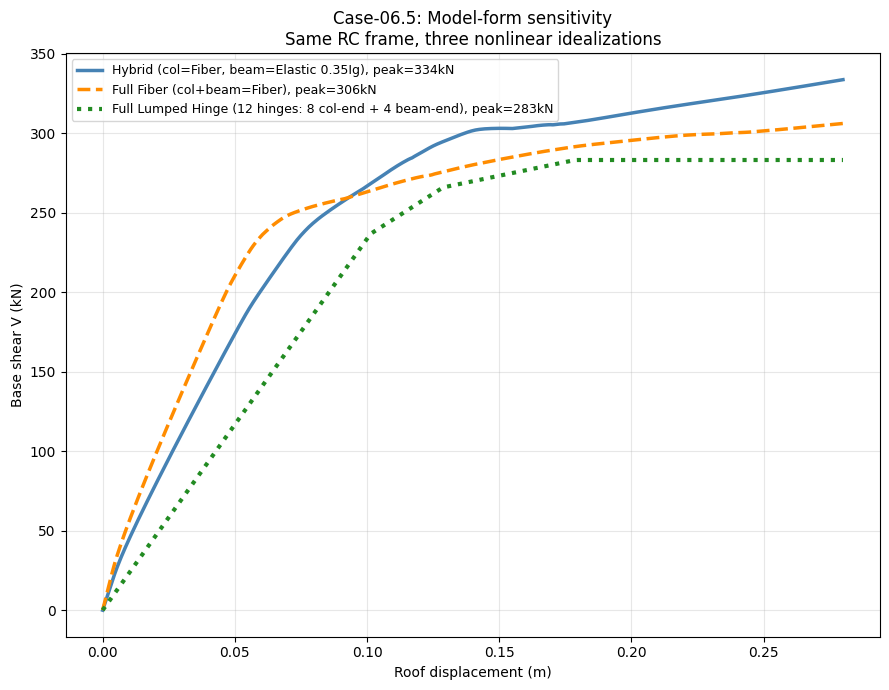

初始勁度(第3步斜率): Hyb=5060, Fib=6618, Hinge=2336 kN/m

三種模型在初始彈性階段已呈現一定程度的剛度差異(柱子的初始EI
假設本來就不同, 纖維斷面切線值跟0.7Ig相差60%); 進入開裂、降伏
與塑性發展後, 容量曲線進一步分岔。這代表建模選擇不僅可能影響
非線性階段, 也會影響結構初始勁度與週期——這點不能用「彈性段
重合」這種沒有資料支持的說法帶過


In [11]:
fig, ax = plt.subplots(figsize=(9,7))
ax.plot(disps, base_shears, '-', color='steelblue', lw=2.5,
        label=f'Hybrid (col=Fiber, beam=Elastic 0.35Ig), peak={base_shears.max():.0f}kN')
ax.plot(d_fib, s_fib, '--', color='darkorange', lw=2.5,
        label=f'Full Fiber (col+beam=Fiber), peak={s_fib.max():.0f}kN')
ax.plot(d_hinge, s_hinge, ':', color='forestgreen', lw=3,
        label=f'Full Lumped Hinge (12 hinges: 8 col-end + 4 beam-end), peak={s_hinge.max():.0f}kN')
ax.set_xlabel('Roof displacement (m)')
ax.set_ylabel('Base shear V (kN)')
ax.set_title('Case-06.5: Model-form sensitivity\nSame RC frame, three nonlinear idealizations')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

K_init_hyb = base_shears[3]/disps[3]
K_init_fib = s_fib[3]/d_fib[3]
K_init_hinge = s_hinge[3]/d_hinge[3]
print(f"初始勁度(第3步斜率): Hyb={K_init_hyb:.0f}, Fib={K_init_fib:.0f}, Hinge={K_init_hinge:.0f} kN/m")
print("\n三種模型在初始彈性階段已呈現一定程度的剛度差異(柱子的初始EI")
print("假設本來就不同, 纖維斷面切線值跟0.7Ig相差60%); 進入開裂、降伏")
print("與塑性發展後, 容量曲線進一步分岔。這代表建模選擇不僅可能影響")
print("非線性階段, 也會影響結構初始勁度與週期——這點不能用「彈性段")
print("重合」這種沒有資料支持的說法帶過")

### 三模型結構示意圖(修正鉸的真實位置與數量)

**這裡也老實更正一個錯誤**:原本這張圖畫的鉸位置(梁跨度 30%/70%
處)跟數量標示(4 柱+2 梁)都不對——**實際程式碼建立的是每根柱兩端
都有鉸(4 根柱×2 端=8 個柱端鉸)、每根梁兩端都有鉸(2 根梁×2 端=
4 個梁端鉸),總共 12 個鉸,而且梁鉸的位置是在梁柱接點,不是跨度
中間的 30%/70%**。圖重畫如下,鉸畫在真正的節點位置上。

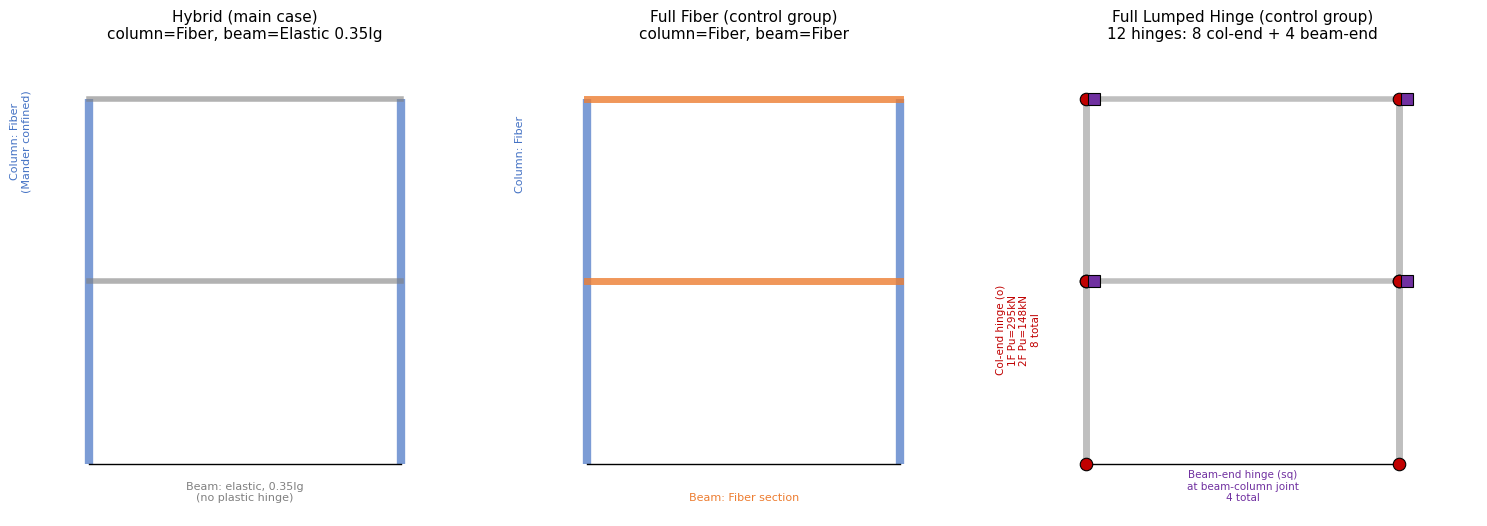

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,7))

def draw_frame_base(ax, title):
    ax.plot([0,L_bay],[0,0],'k-',lw=1)
    ax.set_xlim(-1.5, L_bay+1.5); ax.set_ylim(-1, h1+h2+1)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=11)
    ax.axis('off')

ax = axes[0]
draw_frame_base(ax, 'Hybrid (main case)\ncolumn=Fiber, beam=Elastic 0.35Ig')
for x in [0, L_bay]:
    ax.plot([x,x],[0,h1+h2],color='#4472c4',lw=6,solid_capstyle='butt',alpha=0.7,zorder=1)
ax.plot([0,L_bay],[h1,h1],color='gray',lw=4,alpha=0.6)
ax.plot([0,L_bay],[h1+h2,h1+h2],color='gray',lw=4,alpha=0.6)
ax.text(L_bay/2,-0.7,'Beam: elastic, 0.35Ig\n(no plastic hinge)',ha='center',fontsize=8,color='gray')
ax.text(-1.3,h1+h2/2,'Column: Fiber\n(Mander confined)',ha='center',fontsize=8,color='#4472c4',rotation=90)

ax = axes[1]
draw_frame_base(ax, 'Full Fiber (control group)\ncolumn=Fiber, beam=Fiber')
for x in [0, L_bay]:
    ax.plot([x,x],[0,h1+h2],color='#4472c4',lw=6,solid_capstyle='butt',alpha=0.7,zorder=1)
ax.plot([0,L_bay],[h1,h1],color='#ed7d31',lw=5,alpha=0.8)
ax.plot([0,L_bay],[h1+h2,h1+h2],color='#ed7d31',lw=5,alpha=0.8)
ax.text(L_bay/2,-0.7,'Beam: Fiber section',ha='center',fontsize=8,color='#ed7d31')
ax.text(-1.3,h1+h2/2,'Column: Fiber',ha='center',fontsize=8,color='#4472c4',rotation=90)

ax = axes[2]
draw_frame_base(ax, 'Full Lumped Hinge (control group)\n12 hinges: 8 col-end + 4 beam-end')
for x in [0, L_bay]:
    ax.plot([x,x],[0,h1+h2],color='gray',lw=5,solid_capstyle='butt',alpha=0.5,zorder=1)
ax.plot([0,L_bay],[h1,h1],color='gray',lw=4,alpha=0.5)
ax.plot([0,L_bay],[h1+h2,h1+h2],color='gray',lw=4,alpha=0.5)
col_hinge_pts = [(0,0),(L_bay,0),(0,h1),(L_bay,h1),(0,h1),(L_bay,h1),(0,h1+h2),(L_bay,h1+h2)]
beam_hinge_pts = [(0,h1),(L_bay,h1),(0,h1+h2),(L_bay,h1+h2)]
for (x,y) in col_hinge_pts:
    ax.plot(x,y,'o',color='#c00000',ms=9,zorder=5,markeredgecolor='black',markeredgewidth=0.8)
for (x,y) in beam_hinge_pts:
    ax.plot(x+0.15,y,'s',color='#7030a0',ms=8,zorder=6,markeredgecolor='black',markeredgewidth=0.8)
ax.text(-1.3,h1/2,f'Col-end hinge (o)\n1F Pu={Pu_1F:.0f}kN\n2F Pu={Pu_2F:.0f}kN\n8 total',
        ha='center',fontsize=7.5,color='#c00000',rotation=90)
ax.text(L_bay/2,-0.7,'Beam-end hinge (sq)\nat beam-column joint\n4 total',
        ha='center',fontsize=7.5,color='#7030a0')

plt.tight_layout()
plt.show()

### 主比較表(整合 Case-04.5/06/06.5 的定位,不要混為一談)

三種非線性理想化不是互相競爭的「正確答案」,是三種不同抽象層級的
合理選擇——而 Case-04.5 也不是這三者的第四個對照組,它回答的是
完全不同的問題(彈性框架基準),不應該被拿來跟這裡的非線性結果
直接比較 $K$ 值(這正是上次 $T_e<T_i$ 事件的教訓)。

In [13]:
import pandas as pd

master_table = pd.DataFrame([
    {'Case':'Column-Fiber(Case-06)','結構':'單柱','梁':'—','柱':'Fiber','非線性':'材料積分','用途':'斷面/材料驗證'},
    {'Case':'Case-04.5','結構':'2層構架','梁':'Elastic Ig','柱':'Elastic Ig','非線性':'無(彈性)','用途':'彈性框架基準'},
    {'Case':'Case-06.5 Hyb','結構':'2層構架','梁':'Elastic 0.35Ig','柱':'Fiber','非線性':'混合','用途':'主案例'},
    {'Case':'Case-06.5 Fib','結構':'2層構架','梁':'Fiber','柱':'Fiber','非線性':'分散塑性','用途':'model-form對照'},
    {'Case':'Case-06.5 Hinge','結構':'2層構架','梁':'Elastic 0.35Ig+鉸','柱':'Elastic 0.70Ig+鉸','非線性':'集中塑性(12鉸)','用途':'model-form對照'},
])
print(master_table.to_string(index=False))

                 Case   結構                梁                柱       非線性           用途
Column-Fiber(Case-06)   單柱                —            Fiber      材料積分      斷面/材料驗證
            Case-04.5 2層構架       Elastic Ig       Elastic Ig     無(彈性)       彈性框架基準
        Case-06.5 Hyb 2層構架   Elastic 0.35Ig            Fiber        混合          主案例
        Case-06.5 Fib 2層構架            Fiber            Fiber      分散塑性 model-form對照
      Case-06.5 Hinge 2層構架 Elastic 0.35Ig+鉸 Elastic 0.70Ig+鉸 集中塑性(12鉸) model-form對照


### 三模型各自的 FEMA 356 雙直線化——不只 Hyb 有,Fib/Hinge 也各自算一次

不能只有 Hyb 做過正式的 $0.6V_y$ 割線疊代,另外兩個模型也要各自
獨立算一次自己的 $K_e$、$V_y$、$D_y$、延展性——三組數字各自從
自己的 V-Δ 曲線算出來,不是隨便挑一個代表。

In [14]:
def bilinear_generic(d_arr, s_arr, D_u):
    """通用版0.6Vy割線疊代雙直線化, 給定任意一組(位移,力)資料"""
    def get_V_at_D(D_target):
        return np.interp(D_target, d_arr, s_arr)
    def get_D_at_V(V_target, D_max):
        mask = d_arr <= D_max
        return np.interp(V_target, s_arr[mask], d_arr[mask])
    def area_fn(Vy):
        D_06 = get_D_at_V(0.6*Vy, D_u)
        Ke_ = 0.6*Vy/D_06
        Dy_ = Vy/Ke_
        V_end_ = get_V_at_D(D_u)
        return 0.5*Dy_*Vy + 0.5*(Vy+V_end_)*(D_u-Dy_), Ke_, Dy_, V_end_

    area_real_ = np.trapezoid(s_arr, d_arr)
    Vy_lo, Vy_hi = 50.0, s_arr.max()
    for _ in range(60):
        Vy_mid = (Vy_lo+Vy_hi)/2
        area_bi, _, _, _ = area_fn(Vy_mid)
        if area_bi > area_real_:
            Vy_hi = Vy_mid
        else:
            Vy_lo = Vy_mid
    Vy_final = (Vy_lo+Vy_hi)/2
    _, Ke_final, Dy_final, V_end_final = area_fn(Vy_final)
    return dict(Ke=Ke_final, Vy=Vy_final, Dy=Dy_final, mu=D_u/Dy_final)


bilin_hyb = bilinear_generic(disps, base_shears, disps[-1])
bilin_fib = bilinear_generic(d_fib, s_fib, d_fib[-1])
bilin_hinge = bilinear_generic(d_hinge, s_hinge, d_hinge[-1])

print(f"{'模型':<10}{'Ke(kN/m)':<12}{'Vy(kN)':<10}{'Dy(m)':<10}{'延展性mu'}")
for name, b in [('Hyb', bilin_hyb), ('Fib', bilin_fib), ('Hinge', bilin_hinge)]:
    print(f"{name:<10}{b['Ke']:<12.1f}{b['Vy']:<10.1f}{b['Dy']:<10.4f}{b['mu']:.2f}")

assert abs(bilin_hyb['Ke'] - Ke) < 1.0, "Hyb的通用版計算應與第5課原本算出的Ke一致(互相驗證)"
print("\n[PASS] 通用版函式套用在Hyb上, 跟第5課原本算出的Ke一致, 確認函式本身沒寫錯")

模型        Ke(kN/m)    Vy(kN)    Dy(m)     延展性mu
Hyb       3508.3      271.6     0.0774    3.62
Fib       4468.5      260.2     0.0582    4.81
Hinge     2336.3      272.6     0.1167    2.40

[PASS] 通用版函式套用在Hyb上, 跟第5課原本算出的Ke一致, 確認函式本身沒寫錯


## 總結表

In [15]:
print("="*55)
print("Case-06.5 完整框架V-Delta側推 + FEMA273總結")
print("="*55)
print(f"{'Ke(FEMA356/ASCE41規定的0.6Vy割線勁度)':<24}{Ke:.2f} kN/m")
print(f"{'Dy(降伏位移)':<24}{Dy:.4f} m ({Dy/(h1+h2)*100:.2f}% drift)")
print(f"{'Vy(降伏基底剪力)':<24}{Vy:.2f} kN")
print(f"{'Du(性能目標位移)':<24}{D_u:.4f} m ({D_u/(h1+h2)*100:.2f}% drift)")
print(f"{'延展性mu':<24}{D_u/Dy:.2f}")
print(f"{'與Case-04.5初始勁度差異':<24}{diff_pct:.1f}%")
print()
print("Case-06.5 [PASS] -- 完整2層樓框架V-Delta側推+真正FEMA273完成")
print("Case-06系列(纖維斷面驗證+完整框架側推)至此全部完成")

Case-06.5 完整框架V-Delta側推 + FEMA273總結
Ke(FEMA356/ASCE41規定的0.6Vy割線勁度)3508.27 kN/m
Dy(降伏位移)                0.0774 m (1.11% drift)
Vy(降伏基底剪力)              271.65 kN
Du(性能目標位移)              0.2800 m (4.00% drift)
延展性mu                   3.62
與Case-04.5初始勁度差異        39.0%

Case-06.5 [PASS] -- 完整2層樓框架V-Delta側推+真正FEMA273完成
Case-06系列(纖維斷面驗證+完整框架側推)至此全部完成
